In [82]:
import numpy as np
import pandas as pd
from functions import *
from params import *
from models import *
import scipy.stats as stats
from IPython.display import Markdown

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Path

In [4]:
plot_path='/Users/et/Documents/UNICOG/experiments_data_analysis/memocrush_ext/2_pilote/data_analysis/plots'
processed_file_name='processed_20240416_15h50_memocrush_extension_pilote2_data.csv'
path_processed_data=f'/Users/et/Documents/UNICOG/experiments_data_analysis/memocrush_ext/2_pilote/data_analysis/data/processed/{processed_file_name}'


# Importing data and Formating

In [6]:
### Retrieving the pre-processed Data
df=pd.read_csv(path_processed_data, index_col=False)

### Formatting
df_num=str2int_dataset(df,processed=True, label_int_col=label_int_col)

### Dataframe with only the participants who completed the full experiment/or that have the same amount of trials as max
max_trial=df['counter'].unique()[-1]
data_main=df_num[df_num['participant_ID'].map(df_num['participant_ID'].value_counts()) == max_trial]
data_main.reset_index(inplace=True, drop=True)

### Dataset with no training trials
data_noTraining=data_main.drop(data_main[data_main['seq_name'] == 'Training'].index)
data_noTraining.reset_index(inplace=True, drop=True)

---
# Investigation

## Probability of deleting one element versus one whole chunk

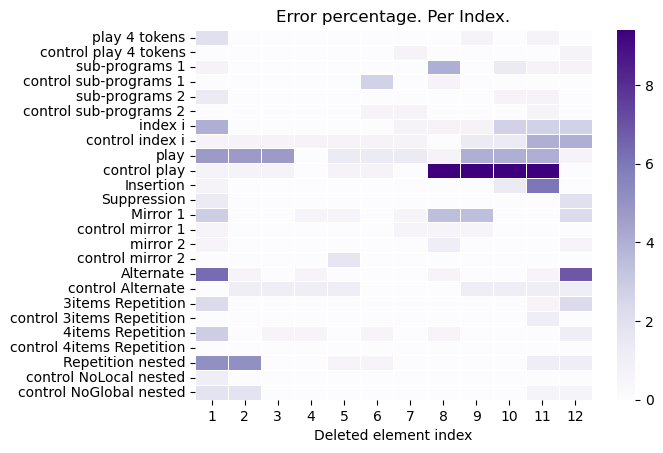

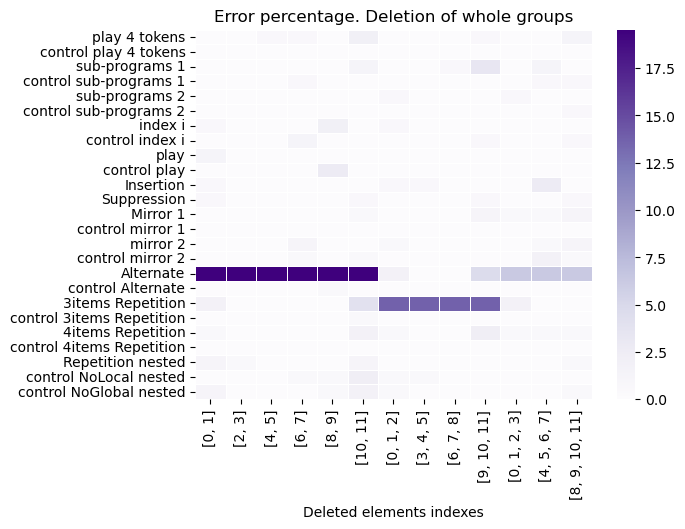

In [52]:
plot_deletion_errors(data_main,plot_path)

<br><br>
## Looking at the reproduced noise from control sequence

In [11]:
data = {
    'seq_name':['one','two','three','three','four','three','three'],
    'sequences_structure': [np.array([0, 1, 2, 3, 4]),
                np.array([2, 3, 4]),
                np.array([0, 1, 2, 3]),
                np.array([0, 1, 2, 3]),
                np.array([1, 2, 3, 4, 5]),
                np.array([0, 1, 2, 3]),
                np.array([0, 1, 2, 3])],
    
    'comparable_temp': [np.array([0, 1, 2]),
                np.array([3, 4, 5]),
                np.array([1, 2]),
                np.array([0, 1, 2, 3, 4, 5]),
                np.array([4, 5]),
                np.array([2, 3, 4]),
                np.array([0, 1, 2])]
}

test_df = pd.DataFrame(data)

In [12]:
#check_transition_probs(data_main, seq_name_list[0],2)

---
# Group analysis : Many different LoTs ?
<ul> My plan and hypothesis
    <li> Dataframe with one column for each mean performance (dl distance) for each sequence. One row = one participant,</li>
    <li> PCA to reduce dimensionality,</li>
    <li> K-means clustering to separate different groups.</li>
</ul>

<b> Interpretation </b> <br>
If we can distinguish different groups, it will either be because some people are just better than others (groups of performance) or because different people use different LoTs (groups of LoTs). The question I want to answer is the following: Can different groups of performance be explained by different LoTs ? Or is it just a difference in working memory capacity ? <br><br>
Groups of performance are nested ? <br>
Groups of performance are not nested ?

In [76]:
not 'control' in control_seq

True

In [78]:
control_seq=[]
for name in seq_name_list:
    if 'control' in name:
        control_seq.append(name)

In [223]:
participant_df=create_participant_df(data_main,exclude=control_seq)

participant_df.shape :  (90, 14)
x_pca.shape :  (90, 5)

 ----------------------------------------
Explained variance:  [0.39228331 0.10591797 0.08385203 0.07095515 0.06739766]
Portion of remaining variance:  0.2795938811879092

 ----------------------------------------


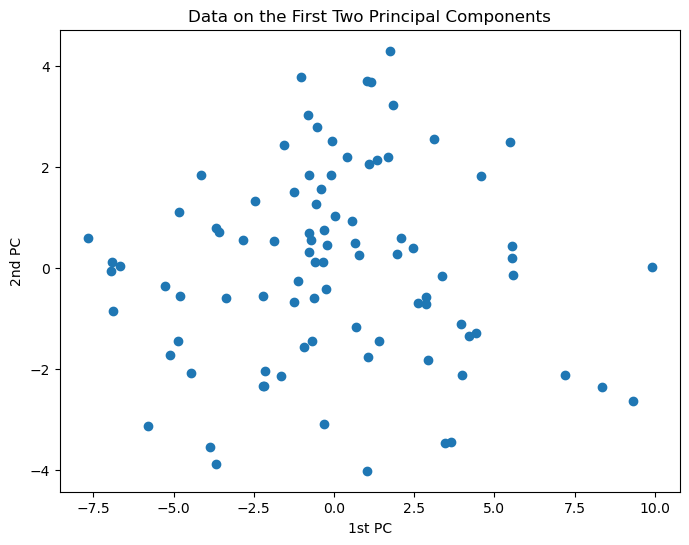


 ----------------------------------------


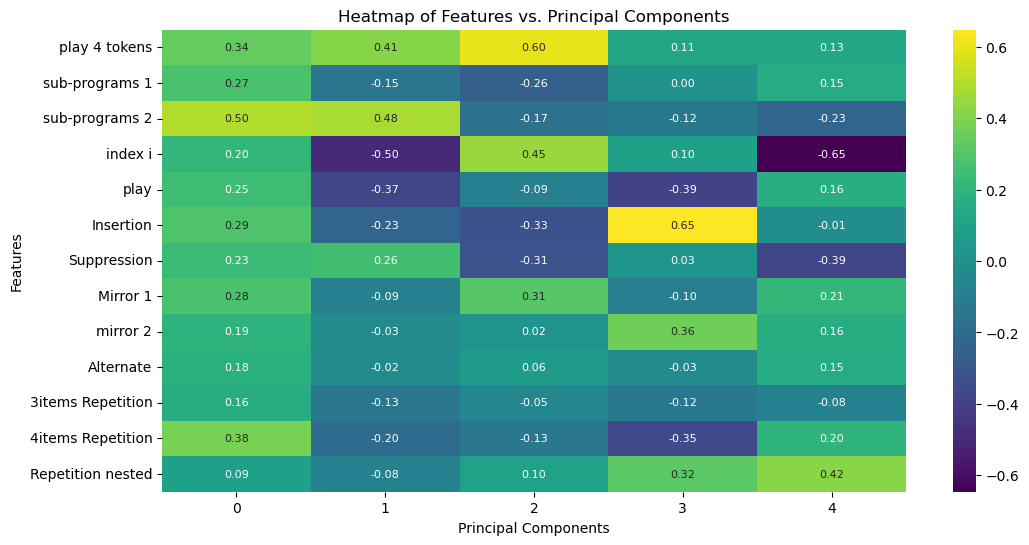

In [118]:
x_pca=perform_PCA(participant_df,pc_nb=5, decide=False)

In [124]:
participant_df.columns

Index(['participant_id', 'play 4 tokens', 'sub-programs 1', 'sub-programs 2',
       'index i', 'play', 'Insertion', 'Suppression', 'Mirror 1', 'mirror 2',
       'Alternate', '3items Repetition', '4items Repetition',
       'Repetition nested'],
      dtype='object')

In [130]:
corr1=participant_df['sub-programs 2'].corr(participant_df['4items Repetition'])
corr2=participant_df['sub-programs 2'].corr(participant_df['mirror 2'])


In [132]:
print(f'Correlation between [sub-programs 2] and [4items Repetition] is : {corr1}')
print(f'Correlation between [sub-programs 2] and [mirror 2] is : {corr2}')


Correlation between [sub-programs 2] and [4items Repetition] is : 0.532559186452058
Correlation between [sub-programs 2] and [mirror 2] is : 0.2912588134365237


participant_df.shape :  (90, 26)
x_pca.shape :  (90, 2)

 ----------------------------------------
Explained variance:  [0.34772724 0.08477597]
Portion of remaining variance:  0.5674967913134439

 ----------------------------------------


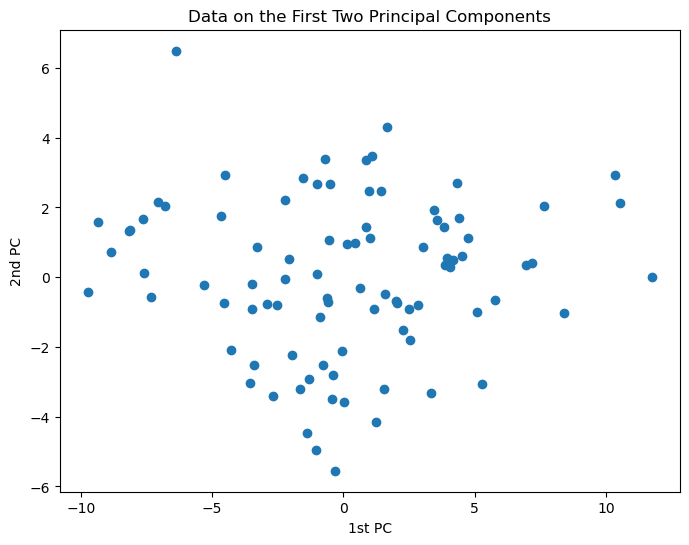


 ----------------------------------------


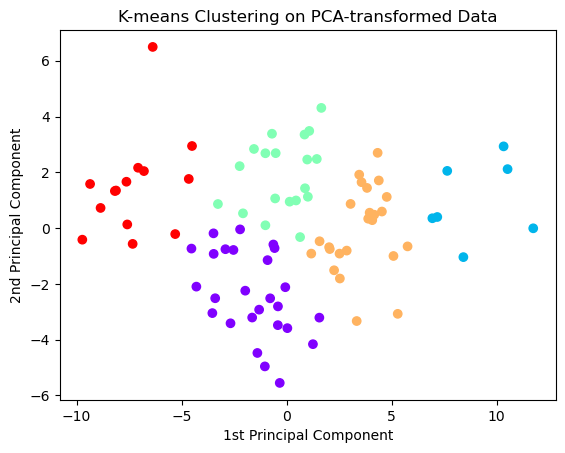

In [50]:
x_pca=perform_PCA(participant_df,heatmap=False)
perform_Kmeans_clustering(x_pca,cluster_nb=5,decide=False)

In [ ]:
correlation_matrix = participant_df.drop('participant_id',axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

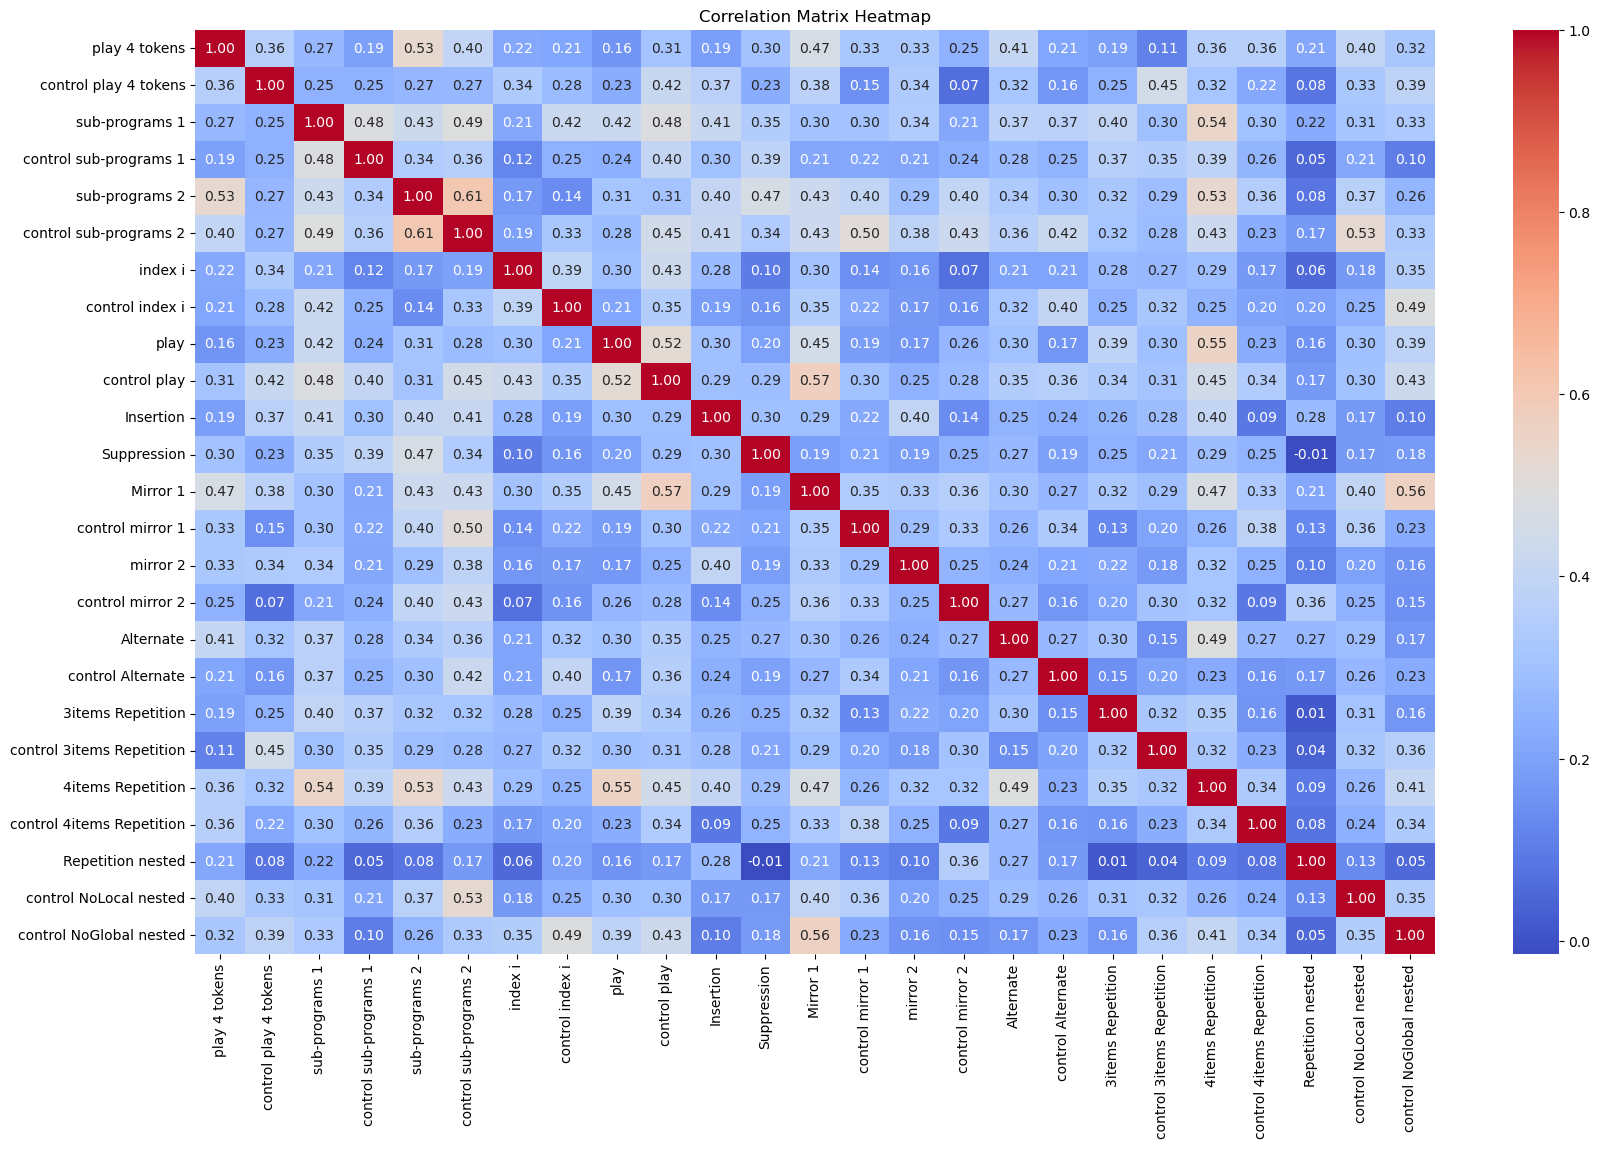

In [229]:
correlation_matrix = participant_df.drop('participant_id',axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

/var/folders/14/1wp2gs4s4k9094qkx6kvfvq00000gn/T/ipykernel_47462/763934296.py:9: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, 'single')


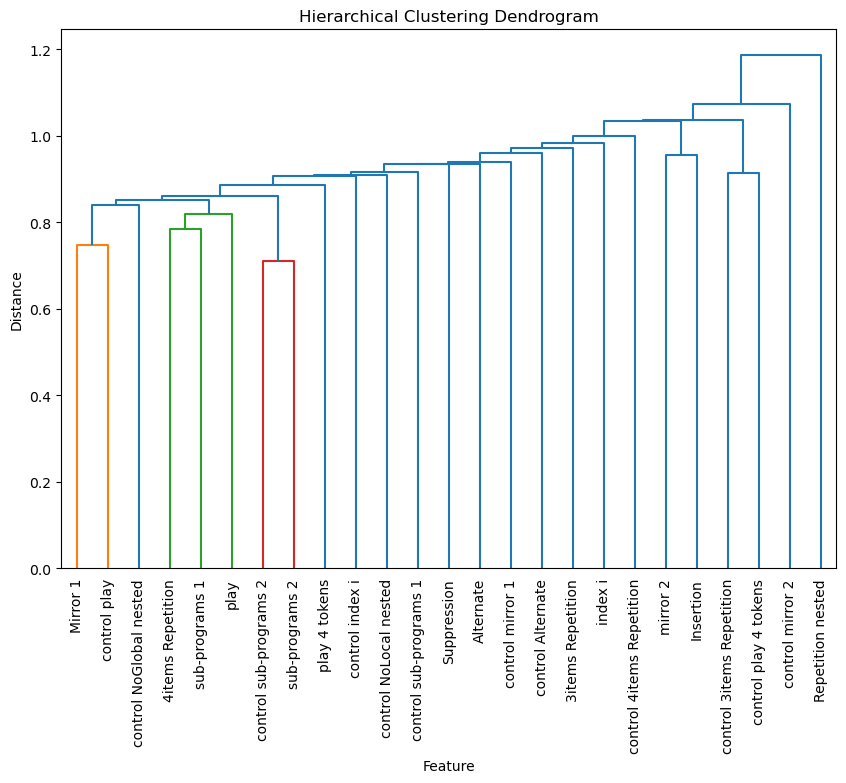

In [241]:
from scipy.cluster.hierarchy import dendrogram, linkage
#  Compute the correlation matrix
correlation_matrix = participant_df.drop('participant_id', axis=1).corr()

# Convert the correlation matrix to a distance matrix (1 - correlation)
distance_matrix = 1 - correlation_matrix

# Perform hierarchical clustering
linked = linkage(distance_matrix, 'single')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=distance_matrix.columns,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.xticks(rotation=90)
plt.ylabel('Distance')
plt.show()

---
# Testing with mock data

In [136]:
test_columns=[i for i in participant_df.columns]

In [138]:
test_columns

['participant_id',
 'play 4 tokens',
 'sub-programs 1',
 'sub-programs 2',
 'index i',
 'play',
 'Insertion',
 'Suppression',
 'Mirror 1',
 'mirror 2',
 'Alternate',
 '3items Repetition',
 '4items Repetition',
 'Repetition nested']

In [243]:
# play and [play_4_tokens, index_i, Insertion, Suppression] are strongly correlation positively
# sub_programs_1 is strongly correlated negatively with sub_programs_2
# mirror1 moderately correlated negatively with mirror2
# alternate strongly correlated positively with items_3rep and items_4rep and nested
import string
def generate_participant_id(length=8):
    letters = string.ascii_uppercase
    return ''.join(random.choice(letters) for i in range(length))


# Set a random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 100

# Generate random data for 'play' column
play = np.random.randn(n_samples)*2+4
sub_programs_1=np.random.randn(n_samples)*2+2
mirror1=np.random.randn(n_samples)*3+4
alternate=np.random.randn(n_samples)*2+4

# Generate 'play_4_tokens' with a correlation of 0.8 with 'play'
# play_4_tokens = 0.8 * play + 0.6 * some_random_noise
noise = np.random.randn(n_samples)*2+4
play_4_tokens = 0.8 * play + 0.6 * noise
sub_programs_2=-0.8 *sub_programs_1+ 0.6 * noise
index_i=0.8 * play + 0.6 * noise
Insertion=0.8 * play + 0.6 * noise
Suppression=0.8 * play + 0.6 * noise
mirror2=-0.5*mirror1+0.6*noise
items_3rep=0.9 * alternate + 0.6 * noise
items_4rep=0.9 * alternate + 0.6 * noise
nested=0.9 * alternate + 0.6 * noise
ids=[generate_participant_id() for _ in range(n_samples)]


# Create a DataFrame
df = pd.DataFrame({
    'participant_id':ids,
    'play': play,
    'play_4_tokens': play_4_tokens,
    'sub_programs_1': sub_programs_1,
    'sub_programs_2': sub_programs_2,
    'mirror1':mirror1,
    'mirror2':mirror2,
    'index_i':index_i,
    'Insertion':Insertion,
    'Suppression':Suppression,
    'alternate':alternate,
    'items_3rep':items_3rep,
    'items_4rep':items_4rep,
    'nested':nested
})


participant_df.shape :  (100, 14)
x_pca.shape :  (100, 3)

 ----------------------------------------
Explained variance:  [0.40150515 0.26117692 0.20125618]
Portion of remaining variance:  0.13606174543595073

 ----------------------------------------


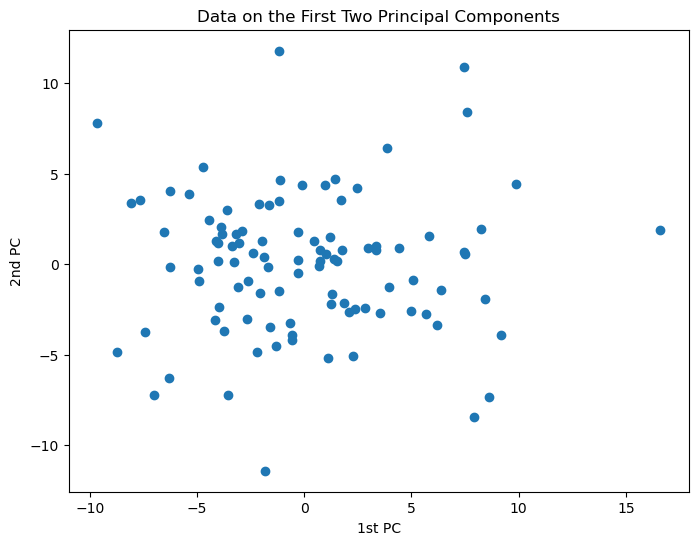


 ----------------------------------------


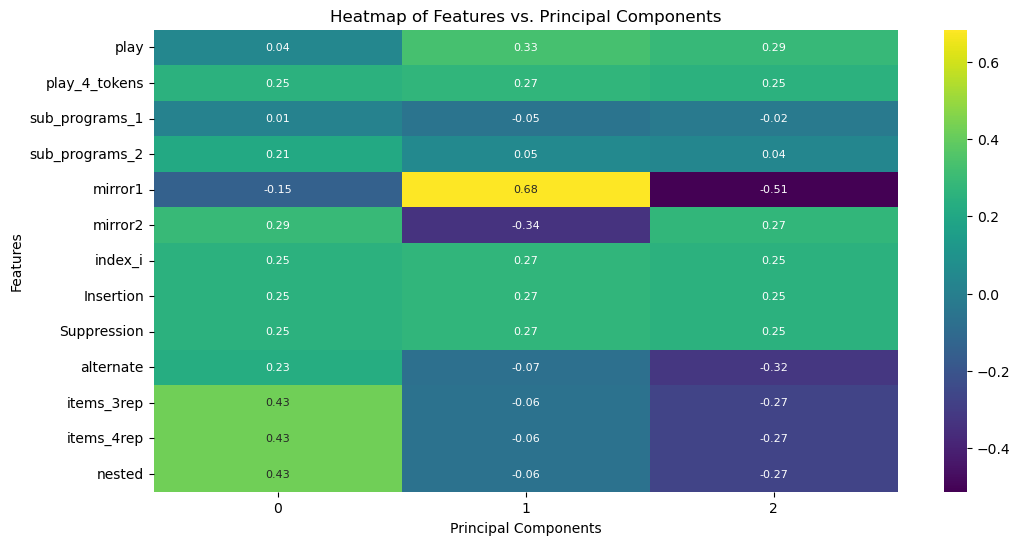

In [190]:
x_pca=perform_PCA(df,pc_nb=3, decide=False)

In [ ]:
# play and [play_4_tokens, index_i, Insertion, Suppression] are strongly correlation positively
# sub_programs_1 is strongly correlated negatively with sub_programs_2
# mirror1 moderately correlated negatively with mirror2
# alternate strongly correlated positively with items_3rep and items_4rep and nested

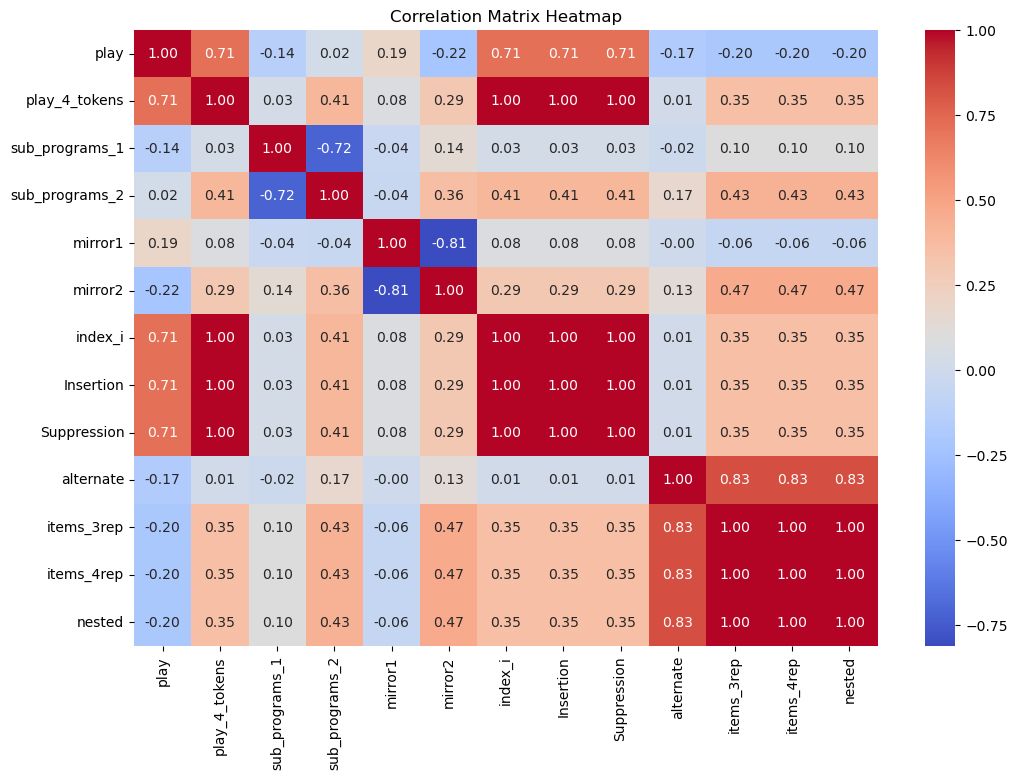

In [196]:
# Compute the correlation matrix
correlation_matrix = df.drop('participant_id',axis=1).corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

/var/folders/14/1wp2gs4s4k9094qkx6kvfvq00000gn/T/ipykernel_47462/81786800.py:9: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, 'single')


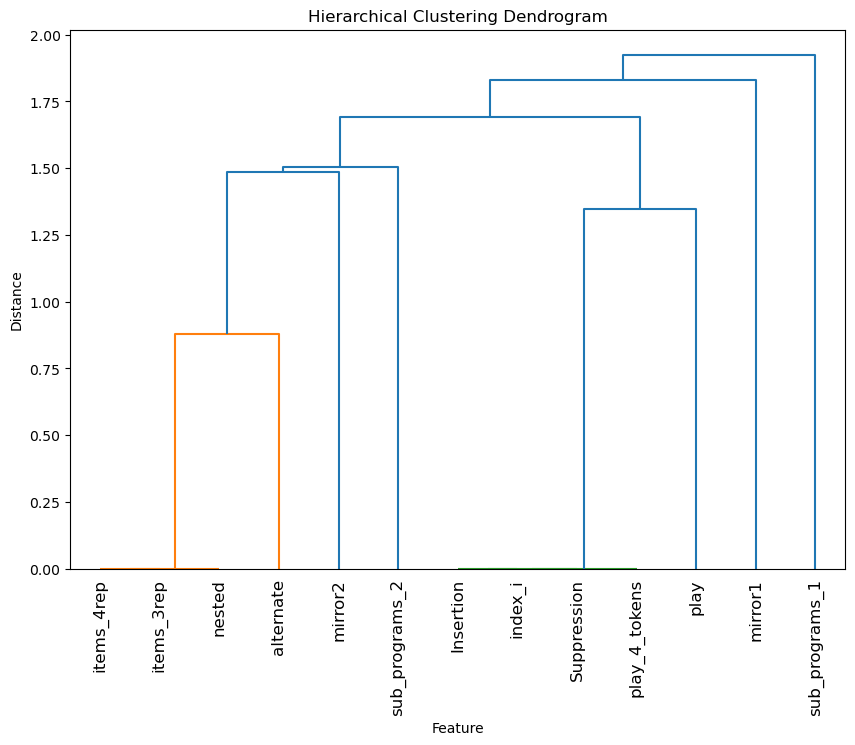

In [245]:
from scipy.cluster.hierarchy import dendrogram, linkage
#  Compute the correlation matrix
correlation_matrix = df.drop('participant_id', axis=1).corr()

# Convert the correlation matrix to a distance matrix (1 - correlation)
distance_matrix = 1 - correlation_matrix

# Perform hierarchical clustering
linked = linkage(distance_matrix, 'single')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=distance_matrix.columns,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Feature')
plt.xticks(rotation=90)
plt.ylabel('Distance')
plt.show()

In [ ]:
# play and [play_4_tokens, index_i, Insertion, Suppression] are strongly correlation positively
# sub_programs_1 is strongly correlated negatively with sub_programs_2
# mirror1 moderately correlated negatively with mirror2
# alternate strongly correlated positively with items_3rep and items_4rep and nested